# Test de visualisation en 2 et 3D via Julia

In [27]:
function nodes()
    n = 0:2
    x = [x for x in n, y in n, z in n][:]
    y = [y for x in n, y in n, z in n][:]
    z = [z for x in n, y in n, z in n][:]

    return x, y, z
end

function edges()
n = 0:2
lx, ly, lz = Float64[], Float64[], Float64[]
    for i in n, j in n
        # tracer une arête sur l'axe X aux coordonnées (i, j) pour y et z
        append!(lx, [0, 2, NaN]); append!(ly, [i, i, NaN]); append!(lz, [j, j, NaN]) 
        append!(lx, [i, i, NaN]); append!(ly, [0, 2, NaN]); append!(lz, [j, j, NaN])
        append!(lx, [i, i, NaN]); append!(ly, [j, j, NaN]); append!(lz, [0, 2, NaN])
    end
    return lx, ly, lz
end

# Noeuds et arêtes
x, y, z = nodes()
lx, ly, lz = edges()


([0.0, 2.0, NaN, 0.0, 0.0, NaN, 0.0, 0.0, NaN, 0.0  …  NaN, 0.0, 2.0, NaN, 2.0, 2.0, NaN, 2.0, 2.0, NaN], [0.0, 0.0, NaN, 0.0, 2.0, NaN, 0.0, 0.0, NaN, 0.0  …  NaN, 2.0, 2.0, NaN, 0.0, 2.0, NaN, 2.0, 2.0, NaN], [0.0, 0.0, NaN, 0.0, 0.0, NaN, 0.0, 2.0, NaN, 1.0  …  NaN, 2.0, 2.0, NaN, 2.0, 2.0, NaN, 0.0, 2.0, NaN])

In [30]:
#ID (1-27) to Coordinates (0-2, 0-2, 0-2)
function id_to_coords(id)
    z = div(id - 1, 9) #id - 1 because Julia indices start at 1
    rem = mod(id - 1, 9) #remainder of the entire division
    y = div(rem, 3)
    x = mod(rem, 3)
    return (x, y, z)
end


#Coord to ID
function coords_to_id(x, y, z)
    return x + 3y + 9z + 1
end

indices_hover = []
indices_hover = [(coords_to_id(x,y,z)) for (x, y, z) in zip(x, y, z)]


27-element Vector{Int64}:
  1
  2
  3
  4
  5
  6
  7
  8
  9
 10
  ⋮
 19
 20
 21
 22
 23
 24
 25
 26
 27

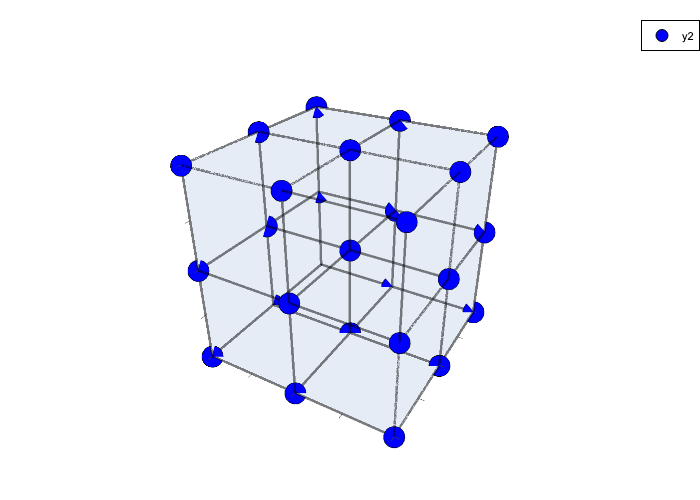

In [32]:
using Plots
plotlyjs() # Pour des plots ineractifs

function plot_cube(x, y, z, lx, ly, lz)
    p = plot(lx, ly, lz, color=:black, alpha=0.5, lw=5, label="")
    scatter!(p, x, y, z, 
            markersize=6, 
            markercolor=:blue, 
            xlims = (0, 2),
            ylims = (0, 2),
            zlims = (0, 2),
            hover = indices_hover,
            ticks=false,      # rm numbers on axes
            showaxis=false,   # rm rows and columns
            grid=false,       # rm grid
            aspect_ratio=:equal,)

    return p
end

p = plot_cube(x, y, z, lx, ly, lz)
display(p)